# **Lifting Equipment Sales & Profit Analytics Dashboard**

## **Business Problem**

Lifting equipment businesses generate sales data across different products, customers, brands, and cities. However, without proper analysis, it becomes difficult to identify which products are performing well, which customers generate the highest revenue, and which cities contribute the most to overall sales.

This project focuses on analyzing lifting equipment sales data to identify important business trends and performance patterns that can support better business decision-making.

---

## **Project Objectives**

- Analyze overall sales and profit performance.
- Identify the best-selling lifting equipment.
- Find the top-performing brands and product categories.
- Analyze city-wise sales performance.
- Identify high-value customers based on revenue.
- Analyze monthly sales trends.
- Generate meaningful business insights through data visualization.
- Support data-driven business decision-making.

---

## **Key Objective**

The key objective of this project is to transform raw lifting equipment sales data into meaningful business insights that help identify sales performance, customer contribution, product demand, and growth opportunities.


## **Data Loading ....................**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("lift.iq.csv")
print(df.head())


       Date  Invoice           Customer             Product Category  Qty  \
0  1/1/2026  INV1001       Tata Steel 1  Chain Pulley Block  Rigging   12   
1  1/2/2026  INV1002  Larsen & Toubro 1         Chain Sling   Safety    5   
2  1/3/2026  INV1003        JSW Steel 1  Chain Pulley Block  Lifting   19   
3  1/4/2026  INV1004     Jindal Steel 1         Chain Sling  Lifting   10   
4  1/5/2026  INV1005             BHEL 1           Web Sling  Rigging    2   

   Unit  Total  GST%       City  
0  3123  37476    18      Noida  
1  4787  23935    18     Jaipur  
2  3116  59204    18     Jaipur  
3  4957  49570    18     Jaipur  
4  6520  13040    18  Faridabad  


# Data Understanding...

- df.head()
- df.tail()
- df.shape
- df.columns
- df.info()

In [26]:
df.head(10)

,Date,Invoice,Customer,Product,Category,Qty,Unit,Total,GST%,City,Cost_price,cost,sales,profit,Profit
0,1/1/2026,INV1001,Tata Steel 1,Chain Pulley Block,Rigging,12,3123,37476,18,Noida,2342.25,28107.00,37476,9369.00,9369.00
1,1/2/2026,INV1002,Larsen & Toubro 1,Chain Sling,Safety,5,4787,23935,18,Jaipur,3590.25,17951.25,23935,5983.75,5983.75
2,1/3/2026,INV1003,JSW Steel 1,Chain Pulley Block,Lifting,19,3116,59204,18,Jaipur,2337.00,44403.00,59204,14801.00,14801.00
3,1/4/2026,INV1004,Jindal Steel 1,Chain Sling,Lifting,10,4957,49570,18,Jaipur,3717.75,37177.50,49570,12392.50,12392.50
4,1/5/2026,INV1005,BHEL 1,Web Sling,Rigging,2,6520,13040,18,Faridabad,4890.00,9780.00,13040,3260.00,3260.00
5,1/6/2026,INV1006,Tata Steel 2,Chain Sling,Lifting,18,6500,117000,18,Faridabad,4875.00,87750.00,117000,29250.00,29250.00
6,1/7/2026,INV1007,Larsen & Toubro 2,Eye Bolt,Lifting,2,5722,11444,18,Faridabad,4291.50,8583.00,11444,2861.00,2861.00
7,1/8/2026,INV1008,JSW Steel 2,Shackle,Rigging,20,2863,57260,18,Gurugram,2147.25,42945.00,57260,14315.00,14315.00
8,1/9/2026,INV1009,Jindal Steel 2,Chain Pulley Block,Rigging,14,4442,62188,18,Gurugram,3331.50,46641.00,62188,15547.00,15547.00
9,1/10/2026,INV1010,BHEL 2,Web Sling,Rigging,16,4488,71808,18,Jaipur,3366.00,53856.00,71808,17952.00,17952.00


In [4]:
df.columns

Index(['Date', 'Invoice', 'Customer', 'Product', 'Category', 'Qty', 'Unit',
       'Total', 'GST%', 'City'],
      dtype='object')

In [5]:
df.tail()

,Date,Invoice,Customer,Product,Category,Qty,Unit,Total,GST%,City
795,2026-03-17,INV1796,Tata Steel 160,Chain Sling,Safety,17,2388,40596,18,Delhi
796,2026-03-18,INV1797,Larsen & Toubro 160,Shackle,Safety,4,7606,30424,18,Delhi
797,2026-03-19,INV1798,JSW Steel 160,Web Sling,Safety,9,7754,69786,18,Noida
798,2026-03-20,INV1799,Jindal Steel 160,Web Sling,Lifting,20,1101,22020,18,Delhi
799,2026-03-21,INV1800,BHEL 160,Turnbuckle,Rigging,13,3440,44720,18,Jaipur


In [6]:
df.shape

(800, 10)

In [7]:
df.columns

Index(['Date', 'Invoice', 'Customer', 'Product', 'Category', 'Qty', 'Unit',
       'Total', 'GST%', 'City'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      800 non-null    object
 1   Invoice   800 non-null    object
 2   Customer  800 non-null    object
 3   Product   800 non-null    object
 4   Category  800 non-null    object
 5   Qty       800 non-null    int64 
 6   Unit      800 non-null    int64 
 7   Total     800 non-null    int64 
 8   GST%      800 non-null    int64 
 9   City      800 non-null    object
dtypes: int64(4), object(6)
memory usage: 62.6+ KB


# Data Cleaning & Feature Engineering...

- Handel Missing Values
- Date Conversion
- Sales Calculation
- Cost Calculation
- Profit Calculation

**Handel Missing Values**

In [9]:
df.dropna(inplace=True)

**Date Conversion**

In [10]:
df["Date"]=pd.to_datetime(df["Date"])

In [11]:
df["Month"]=df["Date"].dt.to_period("M")   #month creation

**Sales Calculation**

In [15]:
df["sales"]=(df["Qty"]*
df["Unit"])

**Cost Calculation**

In [16]:
df["Cost_price"]=df["Unit"]*0.75  #as per information received
df["cost"]=df["Qty"]*df["Cost_price"]

**Profit Calculation**

In [18]:
df["profit"]=(df["sales"]-
df["cost"])

# Exploratory Data Analysis(EDA)...

**Satistical Summary**

In [15]:
df.describe()

,Date,Qty,Unit,Total,GST%,sales,Cost_price,cost,profit
count,800,800.00000,800.000000,800.000000,800.0,800.000000,800.000000,800.000000,800.000000
mean,2026-03-26 12:00:00,10.70125,4250.796250,44758.443750,18.0,44758.443750,3188.097188,33568.832812,11189.610937
min,2026-01-01 00:00:00,1.00000,510.000000,533.000000,18.0,533.000000,382.500000,399.750000,133.250000
25%,2026-02-09 18:00:00,6.00000,2423.500000,16395.250000,18.0,16395.250000,1817.625000,12296.437500,4098.812500
50%,2026-03-21 12:00:00,11.00000,4168.000000,35952.000000,18.0,35952.000000,3126.000000,26964.000000,8988.000000
75%,2026-05-10 06:00:00,16.00000,6168.250000,65366.500000,18.0,65366.500000,4626.187500,49024.875000,16341.625000
max,2026-06-29 00:00:00,20.00000,7992.000000,154480.000000,18.0,154480.000000,5994.000000,115860.000000,38620.000000
std,NaN,5.71295,2172.109892,34558.096404,0.0,34558.096404,1629.082419,25918.572303,8639.524101


**Categorical Data Summary**

In [16]:
df.describe(include="object")

,Invoice,Customer,Product,Category,City
count,800,800,800,800,800
unique,800,800,8,3,5
top,INV1001,Tata Steel 1,Chain Pulley Block,Lifting,Noida
freq,1,1,115,288,164


**Missing Values Analysis**

In [17]:
df.isnull().sum()

Date          0
Invoice       0
Customer      0
Product       0
Category      0
Qty           0
Unit          0
Total         0
GST%          0
City          0
Month         0
sales         0
Cost_price    0
cost          0
profit        0
dtype: int64

**Duplicate Data Check**

In [18]:
df.duplicated().sum()

np.int64(0)

**Unique Values Analysis**

In [19]:
df.nunique()

Date          180
Invoice       800
Customer      800
Product         8
Category        3
Qty            20
Unit          753
Total         794
GST%            1
City            5
Month           6
sales         794
Cost_price    753
cost          794
profit        794
dtype: int64

In [20]:
df["Category"].unique()

array(['Rigging', 'Safety', 'Lifting'], dtype=object)

**Values Count**

In [21]:
df["Category"].value_counts()

Category
Lifting    288
Safety     276
Rigging    236
Name: count, dtype: int64

In [22]:
df["City"].value_counts()

City
Noida        164
Jaipur       161
Gurugram     161
Delhi        160
Faridabad    154
Name: count, dtype: int64

**Numerical Column Distribution**

In [23]:
df["sales"].describe()

count       800.000000
mean      44758.443750
std       34558.096404
min         533.000000
25%       16395.250000
50%       35952.000000
75%       65366.500000
max      154480.000000
Name: sales, dtype: float64

# Business_Analysis & Calculation ...

**Total Sales**  

In [24]:
df["sales"].sum()

np.int64(35806755)

**Total Profit**

In [25]:
df["profit"].sum()

np.float64(8951688.75)

**Total Quantity Sold**

In [26]:
df["Qty"].sum()

np.int64(8561)

**Average Sales Value**

In [27]:
df["sales"].mean()

np.float64(44758.44375)

**Top Selling Products**

In [28]:
df.groupby("Product")["Qty"].sum().sort_values(ascending=False).head(10)

Product
Chain Pulley Block    1267
Shackle               1230
Wire Rope             1132
Hook                  1058
Turnbuckle            1037
Web Sling              980
Chain Sling            968
Eye Bolt               889
Name: Qty, dtype: int64

**Top Performing Categories**

In [29]:
df.groupby("Category")["sales"].sum().sort_values(ascending=False)

Category
Lifting    12624497
Safety     12401878
Rigging    10780380
Name: sales, dtype: int64

**City Wise Sales Performance**

In [30]:
df.groupby("City")["sales"].sum().sort_values(ascending=False)

City
Delhi        7308755
Noida        7261029
Gurugram     7154263
Jaipur       7143509
Faridabad    6939199
Name: sales, dtype: int64

**Date Sales Trend**

In [31]:
df.groupby("Date")["sales"].sum()

Date
2026-01-01    247068
2026-01-02    333119
2026-01-03    330792
2026-01-04    216607
2026-01-05    228766
               ...  
2026-06-25    257953
2026-06-26    199218
2026-06-27     91616
2026-06-28    125066
2026-06-29    279464
Name: sales, Length: 180, dtype: int64

# Profit Analysis ...

**Cost_price Calculate & Profit Check...**

In [28]:
df["Cost_price"]=df["Unit"]*0.75
df["cost"]=df["Qty"]*df["Cost_price"]
df["Profit"]=df["sales"]-df["cost"]


In [29]:
df[["sales","Cost_price","Profit"]].head()

,sales,Cost_price,Profit
0,37476,2342.25,9369.00
1,23935,3590.25,5983.75
2,59204,2337.00,14801.00
3,49570,3717.75,12392.50
4,13040,4890.00,3260.00


**Total_Profit**

In [30]:
df["Profit"].sum()

np.float64(8951688.75)

**Product_Wise Profit**

In [31]:
(df.groupby("Product")
    ["Profit"].sum().sort_values(ascending=False).head())

Product
Chain Pulley Block    1273576.75
Shackle               1238788.00
Turnbuckle            1163817.50
Wire Rope             1158988.75
Web Sling             1063473.50
Name: Profit, dtype: float64

**Category_Wise Profit**

In [37]:
(df.groupby("Category")
    ["Profit"].sum().sort_values(ascending=False))

Category
Lifting    11689244.00
Safety     11527354.75
Rigging    10039678.50
Name: Profit, dtype: float64

**City_Wise Profit**

In [38]:
(df.groupby("City")
    ["Profit"].sum().sort_values(ascending=False))

City
Noida        6775980.00
Delhi        6767009.75
Jaipur       6664492.25
Gurugram     6631502.50
Faridabad    6417292.75
Name: Profit, dtype: float64

**Customer_Wise Profit**

In [39]:
(df.groupby("Customer")
    ["Profit"].sum().sort_values(ascending=False))

Customer
Jindal Steel 76        148687.00
Tata Steel 114         148071.00
Tata Steel 108         147589.75
JSW Steel 142          142777.25
Larsen & Toubro 22     142642.00
                         ...    
JSW Steel 154             322.50
JSW Steel 131             289.25
Jindal Steel 153          284.75
BHEL 75                   134.75
Larsen & Toubro 113       133.25
Name: Profit, Length: 800, dtype: float64

**Margin_Wise Profit**

In [40]:
df["Profit_margin"]=(df["Profit"]/df["sales"])*100
df["Profit_margin"]

0      93.750000
1      85.000000
2      96.052632
3      92.500000
4      62.500000
         ...    
795    95.588235
796    81.250000
797    91.666667
798    96.250000
799    94.230769
Name: Profit_margin, Length: 800, dtype: float64

# Product Analysis ...

**Maximum_Sales Product**

In [41]:
(df.groupby("Product")
       ["sales"].sum().idxmax())

'Chain Pulley Block'

**Minimum_Sales Product**

In [42]:
(df.groupby("Product")
       ["sales"].sum().idxmin())

'Eye Bolt'

**Top 10 Least_Selling Product**

In [43]:
(df.groupby("Product")
       ["Unit"].sum().sort_values(ascending=True).head(10))

Product
Eye Bolt              345748
Chain Sling           366982
Web Sling             405330
Hook                  432530
Wire Rope             442809
Shackle               446091
Turnbuckle            474334
Chain Pulley Block    486813
Name: Unit, dtype: int64

**Top 10 Profitable Product**

In [44]:
(df.groupby("Product")
       ["Profit"].sum().sort_values(ascending=True).head(10))

Product
Eye Bolt              3659531.00
Chain Sling           3836254.50
Hook                  3857446.50
Web Sling             3949896.50
Turnbuckle            4299519.50
Wire Rope             4303848.25
Shackle               4620583.75
Chain Pulley Block    4729197.25
Name: Profit, dtype: float64

**Top 10 Product by Sales**

In [45]:
(df.groupby("Product")
       ["sales"].sum().sort_values(ascending=True).head(10))

Product
Eye Bolt              3918842
Chain Sling           4111491
Hook                  4181844
Web Sling             4253894
Wire Rope             4635955
Turnbuckle            4655270
Shackle               4955152
Chain Pulley Block    5094307
Name: sales, dtype: int64

**Top 10 Selling_Product**

In [46]:
(df.groupby("Product")
       ["Unit"].sum().sort_values(ascending=False).head(10))

Product
Chain Pulley Block    486813
Turnbuckle            474334
Shackle               446091
Wire Rope             442809
Hook                  432530
Web Sling             405330
Chain Sling           366982
Eye Bolt              345748
Name: Unit, dtype: int64

**Total_Unique Product**

In [47]:
print("Total Unique Products:",
      df["Product"].nunique())
print("\nProduct Names:")
print(df["Product"].unique())

Total Unique Products: 8

Product Names:
['Chain Pulley Block' 'Chain Sling' 'Web Sling' 'Eye Bolt' 'Shackle'
 'Wire Rope' 'Hook' 'Turnbuckle']


# Data Visualization ....

**Total Sales**


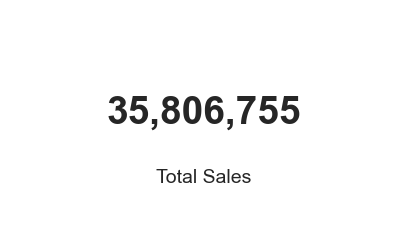

In [24]:
total_sales=df["sales"].sum()
plt.figure(figsize=(5,3))

plt.text(0.5,0.55,f"{total_sales:,.0f}",
         fontsize=28,
         fontweight="bold",
         ha="center",
         va="center")




plt.text(0.5,0.25,
         "Total Sales",
         fontsize=14,
         ha="center"
)

plt.axis("off")
plt.show()

**Least 3 Sales Product**

**Category_Wise Sales**

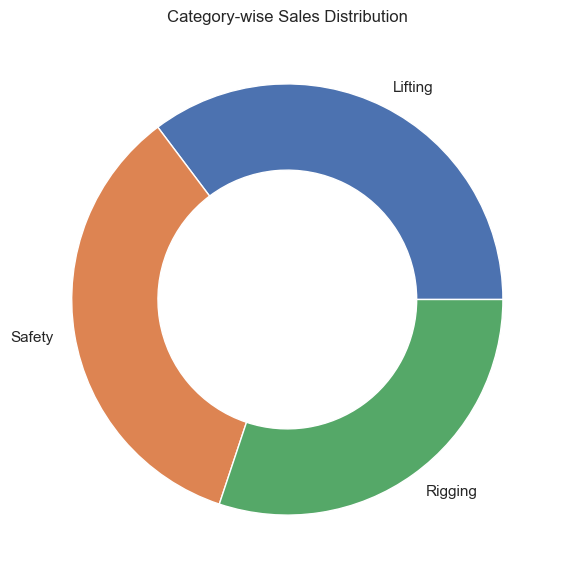

In [22]:
sns.set_theme(style="white")

category_sales = (
    df.groupby("Category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,7))

plt.pie(
    category_sales,
    labels=category_sales.index,
    wedgeprops={"width":0.4, "edgecolor":"white"}
)

plt.title("Category-wise Sales Distribution")
plt.show()


**City_Wise Sales**

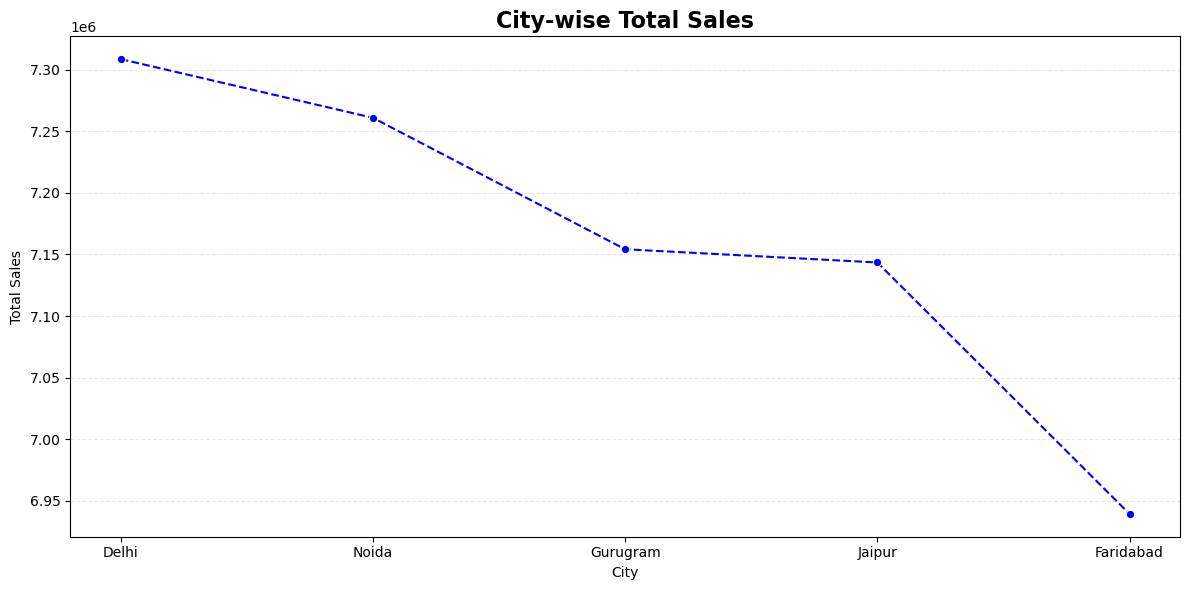

In [21]:
city_sales = (
    df.groupby("City")["sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))

# Scatter + Line
sns.lineplot(
    data=city_sales,
    x="City",
    y="sales",
    marker="o",
    linestyle="--",
    color="Blue"
)


plt.title("City-wise Total Sales", fontsize=16, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


**Top 3 Profitable Product**

C:\Users\jwala ji computer\AppData\Local\Temp\ipykernel_14036\3641551093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_profit, x="Profit", y="Product", palette="Pastel1")


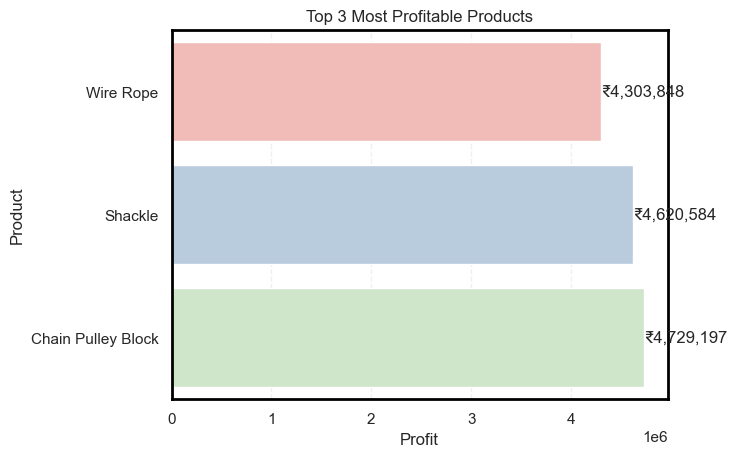

In [71]:
top_profit = df.groupby("Product")["Profit"].sum().nlargest(3).sort_values().reset_index()

ax = sns.barplot(data=top_profit, x="Profit", y="Product", palette="Pastel1")

for i, v in enumerate(top_profit["Profit"]):
    ax.text(v, i, f"₹{v:,.0f}", va="center")

plt.title("Top 3 Most Profitable Products")
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color("black")    # Border color
    spine.set_linewidth(2)      # Border thickness

plt.grid(axis="x", ls="--", alpha=0.3)
plt.show()
